<a href="https://colab.research.google.com/github/pacayton/DS_397_Interpretable_ML/blob/main/DS397_Interpretable_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Preamble code

## Packages to install

install.packages(c("tidyverse", "ISLR", "rpart", "gam"))


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(tidyverse)
library(ISLR)
library(rpart)
library(gam)

Loading required package: splines

Loading required package: foreach


Attaching package: ‘foreach’


The following objects are masked from ‘package:purrr’:

    accumulate, when


Loaded gam 1.22-7




Source Data: https://github.com/christophM/interpretable-ml-book/tree/master/data

In [ ]:
## Data Upload

bike <- read_csv("https://github.com/christophM/interpretable-ml-book/raw/refs/heads/master/data/bike.csv")

bike

Rows: 728 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (6): season, mnth, holiday, weekday, workday, weather
dbl  (11): instant, yr, temp, atemp, hum, windspeed, casual, registered, cnt...
date  (1): dteday

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


instant,dteday,season,yr,mnth,holiday,weekday,temp,atemp,hum,windspeed,casual,registered,cnt,workday,weather,days_since_2011,cnt_2d_bfr
<dbl>,<date>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
3,2011-01-03,WINTER,2011,JAN,N,MON,1.229108,22.43977,43.7273,16.636703,120,1229,1349,Y,GOOD,2,985
4,2011-01-04,WINTER,2011,JAN,N,TUE,1.400000,23.21215,59.0435,10.739832,108,1454,1562,Y,GOOD,3,801
5,2011-01-05,WINTER,2011,JAN,N,WED,2.666979,23.79518,43.6957,12.522300,82,1518,1600,Y,GOOD,4,1349
6,2011-01-06,WINTER,2011,JAN,N,THU,1.604356,23.92911,51.8261,6.000868,88,1518,1606,Y,GOOD,5,1562
7,2011-01-07,WINTER,2011,JAN,N,FRI,1.236534,23.10053,49.8696,11.304642,148,1362,1510,Y,MISTY,6,1600
8,2011-01-08,WINTER,2011,JAN,N,SAT,-0.245000,21.51664,53.5833,17.875868,68,891,959,N,MISTY,7,1606
9,2011-01-09,WINTER,2011,JAN,N,SUN,-1.498349,19.94995,43.4167,24.250650,54,768,822,N,GOOD,8,1510
10,2011-01-10,WINTER,2011,JAN,N,MON,-0.910849,21.13019,48.2917,14.958889,41,1280,1321,Y,GOOD,9,959
11,2011-01-11,WINTER,2011,JAN,N,TUE,-0.052723,22.50978,68.6364,8.182844,43,1220,1263,Y,MISTY,10,822


In [ ]:
penguins <- read_csv("https://github.com/christophM/interpretable-ml-book/raw/refs/heads/master/data/penguins.csv")

penguins

Rows: 344 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): species, island, sex
dbl (6): rowid, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
2,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
3,Adelie,Torgersen,40.3,18.0,195,3250,female,2007
4,Adelie,Torgersen,NA,NA,NA,NA,NA,2007
5,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
6,Adelie,Torgersen,39.3,20.6,190,3650,male,2007
7,Adelie,Torgersen,38.9,17.8,181,3625,female,2007
8,Adelie,Torgersen,39.2,19.6,195,4675,male,2007
9,Adelie,Torgersen,34.1,18.1,193,3475,NA,2007


In [ ]:
## Linear Regression

## Using the Bike Dataset

## Data Cleaning: Removing rows with missing data
bike <- na.omit(bike)

#summary(bike)

## Selected Features
bike_features <- c("season", "holiday", "weekday", "weather", "temp",
                   "hum", "windspeed", "cnt_2d_bfr")

## Keeping Variables to Use
bike <- bike[,c(bike_features, "cnt")]

## Train-Test Split
set.seed(20260209)
bike_train_index <- sample(1:nrow(bike), 2/3*nrow(bike))
bike_train <- bike[bike_train_index,]
bike_test <- bike[-bike_train_index,]



In [ ]:
## Estimate Model

bike_lm <- lm(cnt ~ . , data = bike_train)

summary(bike_lm)


Call:
lm(formula = cnt ~ ., data = bike_train)

Residuals:
    Min      1Q  Median      3Q     Max 
-3615.4  -570.4   -43.5   602.4  3764.5 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1719.85356  539.43365   3.188 0.001527 ** 
seasonSPRING -188.75837  140.02958  -1.348 0.178314    
seasonSUMMER -510.71346  178.90920  -2.855 0.004500 ** 
seasonWINTER -540.31430  148.45356  -3.640 0.000303 ***
holidayY     -490.47313  258.63802  -1.896 0.058527 .  
weekdayMON   -420.61747  172.41750  -2.440 0.015077 *  
weekdaySAT   -255.11502  167.08379  -1.527 0.127469    
weekdaySUN   -663.82746  162.06608  -4.096 4.95e-05 ***
weekdayTHU   -113.76081  166.50143  -0.683 0.494792    
weekdayTUE    -37.99615  164.07186  -0.232 0.816964    
weekdayWED   -146.65187  165.35497  -0.887 0.375593    
weatherGOOD  1872.21417  294.16992   6.364 4.68e-10 ***
weatherMISTY 1498.62528  268.62690   5.579 4.10e-08 ***
temp           58.21752   10.15138   5.735 1.75e-08 ***
hum

In [ ]:
unique(bike$weather)

[1] "GOOD"  "MISTY" "BAD"

In [ ]:
bike_lm2 <- lm(cnt ~ . + I(temp^2) + I(hum^2)  , data = bike_train)

summary(bike_lm2)


Call:
lm(formula = cnt ~ . + I(temp^2) + I(hum^2), data = bike_train)

Residuals:
    Min      1Q  Median      3Q     Max 
-3512.2  -520.4   -66.6   537.8  3479.3 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -722.31723  754.92996  -0.957 0.339164    
seasonSPRING -109.31324  131.92910  -0.829 0.407769    
seasonSUMMER   -4.74009  179.63480  -0.026 0.978960    
seasonWINTER -236.11747  144.39333  -1.635 0.102674    
holidayY     -507.27683  242.71573  -2.090 0.037159 *  
weekdayMON   -378.49124  161.75525  -2.340 0.019710 *  
weekdaySAT   -159.01801  157.23863  -1.011 0.312390    
weekdaySUN   -584.50957  152.49153  -3.833 0.000144 ***
weekdayTHU    -63.32786  156.23591  -0.405 0.685417    
weekdayTUE     17.14494  154.03425   0.111 0.911422    
weekdayWED   -113.23198  155.07523  -0.730 0.465650    
weatherGOOD  1426.25042  296.67695   4.807 2.07e-06 ***
weatherMISTY 1114.99353  268.94672   4.146 4.02e-05 ***
temp          230.16927   24.39421  

In [ ]:
#' Plot coefficients of a linear model
coef_plot = function(mod, alpha = 0.05, remove_intercept = TRUE){
  lm_summary = summary(mod)$coefficients

  df = data.frame(Features = rownames(lm_summary),
    Estimate = lm_summary[,'Estimate'],
    std_error = lm_summary[,'Std. Error'])
  df$lower = df$Estimate + qnorm(alpha/2) * df$std_error
  df$upper = df$Estimate - qnorm(alpha/2) * df$std_error


  if(remove_intercept){
    df = df[!(df$Features == '(Intercept)'),]
  }
  require("ggplot2")
  ggplot(df) +
    geom_vline(xintercept=0, linetype=4) +
    geom_point(aes(x=Estimate, y=Features)) +
    geom_segment(aes(y=Features, yend=Features, x=lower, xend=upper), arrow = arrow(angle=90, ends='both', length = unit(0.1, 'cm'))) +
    scale_x_continuous('Weight estimate')
}

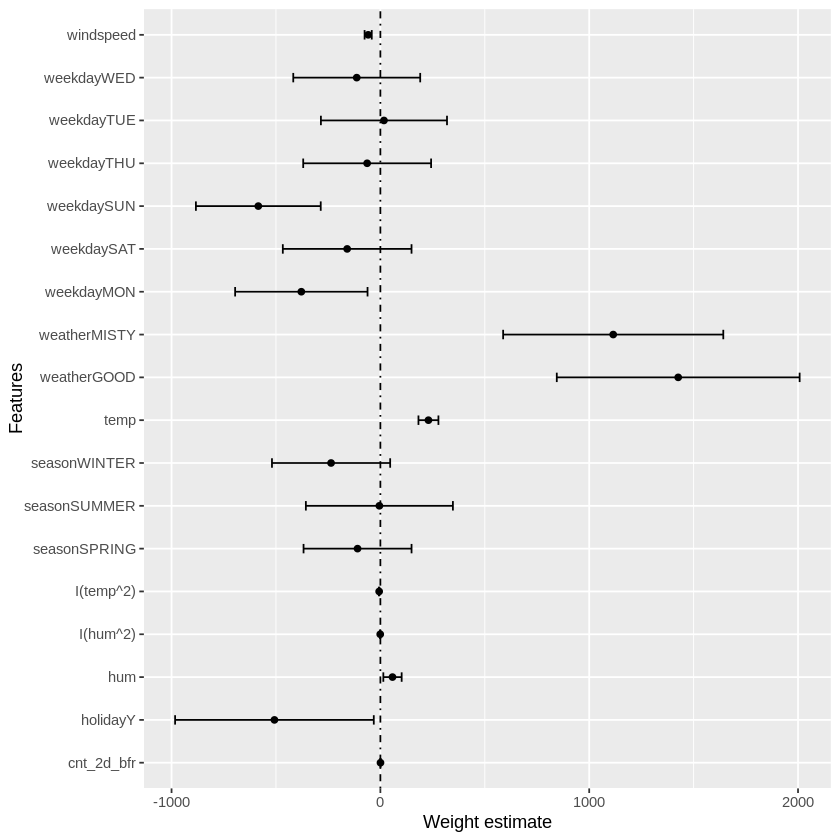

In [ ]:
coef_plot(bike_lm2)

In [ ]:
## Logistic Regression

## Data Cleaning; Removing Rows with Missing Data
penguins <- na.omit(penguins)

penguins_orig <- penguins

## Coding for Females
penguins$sex <- ifelse(penguins$sex == "female", 1,0)

## Variables to Use
penguins_cols_selection <- c("species", "bill_depth_mm", "bill_length_mm",
                             "flipper_length_mm", "sex", "body_mass_g")
## Selecting Variables in the Dataset
penguins <- penguins[,penguins_cols_selection]

# Train-Test Split
penguins_train_index <- sample(1:nrow(penguins), 2/3*nrow(penguins))
penguins_train <- penguins[penguins_train_index,]
penguins_test <- penguins[-penguins_train_index,]

In [ ]:
penguins

species,bill_depth_mm,bill_length_mm,flipper_length_mm,sex,body_mass_g
<chr>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>
Adelie,18.7,39.1,181,male,3750
Adelie,17.4,39.5,186,female,3800
Adelie,18.0,40.3,195,female,3250
Adelie,19.3,36.7,193,female,3450
Adelie,20.6,39.3,190,male,3650
Adelie,17.8,38.9,181,female,3625
Adelie,19.6,39.2,195,male,4675
Adelie,17.6,41.1,182,female,3200
Adelie,21.2,38.6,191,male,3800


In [ ]:
summary(penguins)

   species          bill_depth_mm   bill_length_mm  flipper_length_mm
 Length:333         Min.   :13.10   Min.   :32.10   Min.   :172      
 Class :character   1st Qu.:15.60   1st Qu.:39.50   1st Qu.:190      
 Mode  :character   Median :17.30   Median :44.50   Median :197      
                    Mean   :17.16   Mean   :43.99   Mean   :201      
                    3rd Qu.:18.70   3rd Qu.:48.60   3rd Qu.:213      
                    Max.   :21.50   Max.   :59.60   Max.   :231      
     sex             body_mass_g  
 Length:333         Min.   :2700  
 Class :character   1st Qu.:3550  
 Mode  :character   Median :4050  
                    Mean   :4207  
                    3rd Qu.:4775  
                    Max.   :6300  

In [ ]:
penguins_glm <- glm(sex ~ . , data = penguins_train,
                    family=binomial(link = "logit"))

summary(penguins_glm)


Call:
glm(formula = sex ~ ., family = binomial(link = "logit"), data = penguins_train)

Coefficients:
                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)       103.338883  21.446918   4.818 1.45e-06 ***
speciesChinstrap   10.906645   2.878222   3.789 0.000151 ***
speciesGentoo      13.026154   4.432962   2.938 0.003298 ** 
bill_depth_mm      -2.074064   0.558290  -3.715 0.000203 ***
bill_length_mm     -1.127883   0.263681  -4.277 1.89e-05 ***
flipper_length_mm   0.052234   0.083011   0.629 0.529189    
body_mass_g        -0.008585   0.001905  -4.506 6.60e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 307.595  on 221  degrees of freedom
Residual deviance:  62.245  on 215  degrees of freedom
AIC: 76.245

Number of Fisher Scoring iterations: 8


In [ ]:
## GAMs

bike_gam <- gam(cnt ~ s(temp, 4) + ns(hum, 4) + cnt_2d_bfr
+ holiday, data = bike_train)

summary(bike_gam)


Call: gam(formula = cnt ~ s(temp, 4) + ns(hum, 4) + cnt_2d_bfr + holiday, 
    data = bike_train)
Deviance Residuals:
     Min       1Q   Median       3Q      Max 
-4888.85  -617.45   -43.26   579.21  3707.89 

(Dispersion Parameter for gaussian family taken to be 946518.6)

    Null Deviance: 1762541249 on 484 degrees of freedom
Residual Deviance: 448649584 on 473.9997 degrees of freedom
AIC: 8063.109 

Number of Local Scoring Iterations: NA 

Anova for Parametric Effects
            Df    Sum Sq   Mean Sq  F value Pr(>F)    
s(temp, 4)   1 702438462 702438462 742.1285 <2e-16 ***
ns(hum, 4)   4 179862509  44965627  47.5063 <2e-16 ***
cnt_2d_bfr   1 318450666 318450666 336.4442 <2e-16 ***
holiday      1   5450339   5450339   5.7583 0.0168 *  
Residuals  474 448649584    946519                    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Anova for Nonparametric Effects
            Npar Df Npar F     Pr(F)    
(Intercept)                             
s(temp, 4

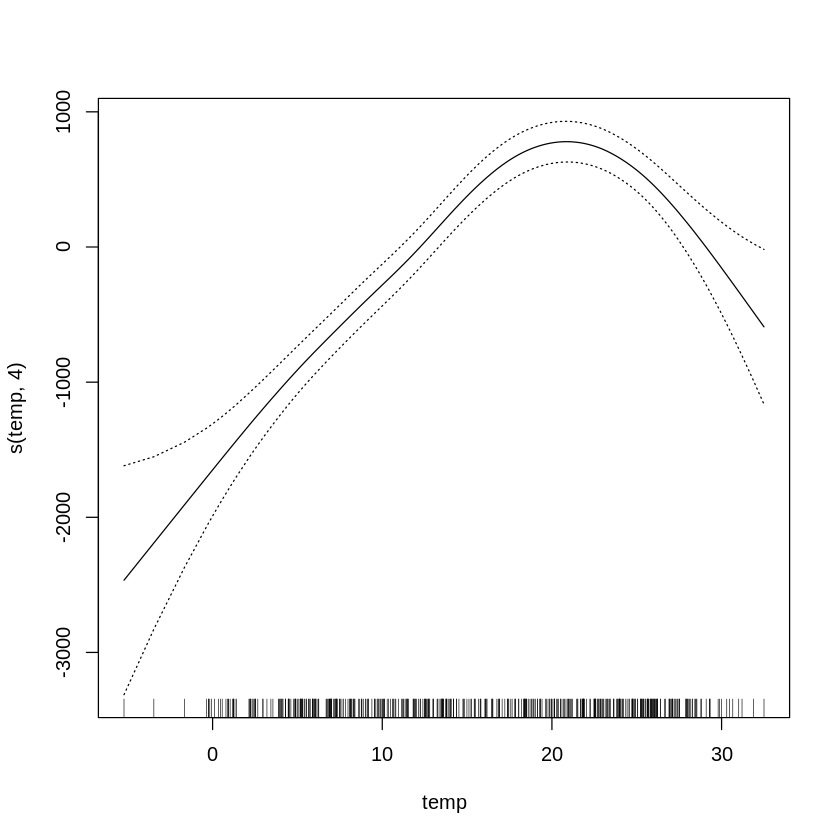

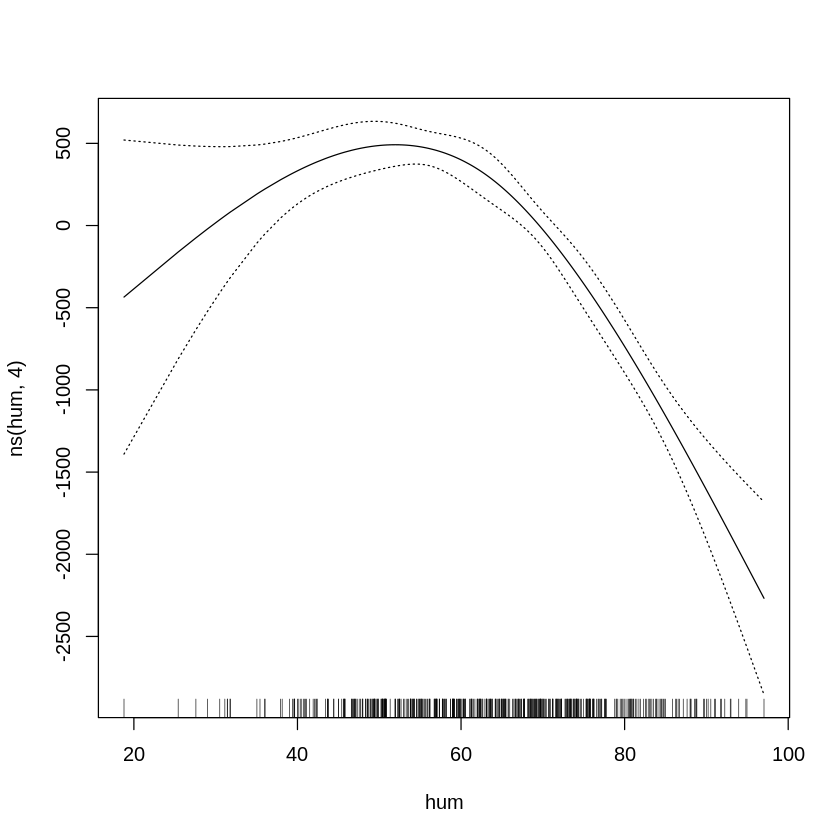

Warning message in gplot.default(x = c("N", "N", "N", "N", "N", "N", "N", "N", "N", :
“The "x" component of "partial for holiday" has class "character"; no gplot() methods available”


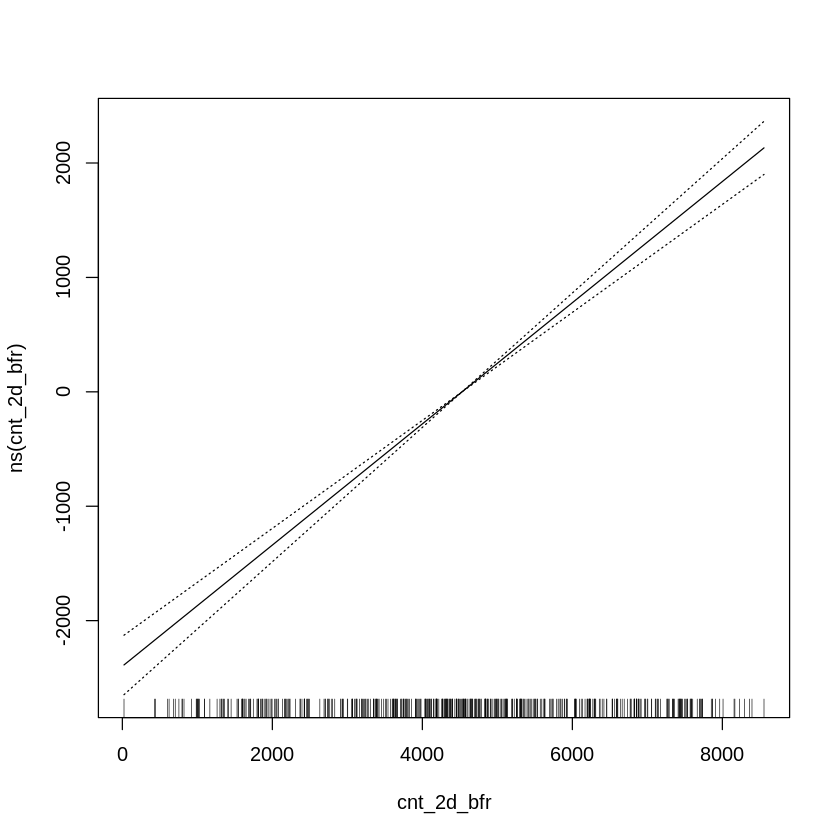

In [ ]:
plot.Gam(bike_gam, se=TRUE)


Call: gam(formula = sex ~ s(bill_depth_mm, 4) + s(bill_length_mm, 4) + 
    s(flipper_length_mm, 4) + s(body_mass_g) + species, family = binomial, 
    data = penguins_train)
Deviance Residuals:
       Min         1Q     Median         3Q        Max 
-2.6147487 -0.0545546  0.0003792  0.0551351  2.1888894 

(Dispersion Parameter for binomial family taken to be 1)

    Null Deviance: 307.5952 on 221 degrees of freedom
Residual Deviance: 49.8532 on 202.9994 degrees of freedom
AIC: 87.8544 

Number of Local Scoring Iterations: NA 

Anova for Parametric Effects
                         Df Sum Sq Mean Sq F value    Pr(>F)    
s(bill_depth_mm, 4)       1  0.165  0.1647   0.467 0.4951665    
s(bill_length_mm, 4)      1  4.955  4.9549  14.052 0.0002319 ***
s(flipper_length_mm, 4)   1  9.458  9.4582  26.823 5.355e-07 ***
s(body_mass_g)            1 13.843 13.8427  39.257 2.184e-09 ***
species                   2 13.123  6.5614  18.608 3.801e-08 ***
Residuals               203 71.581  0.3526    

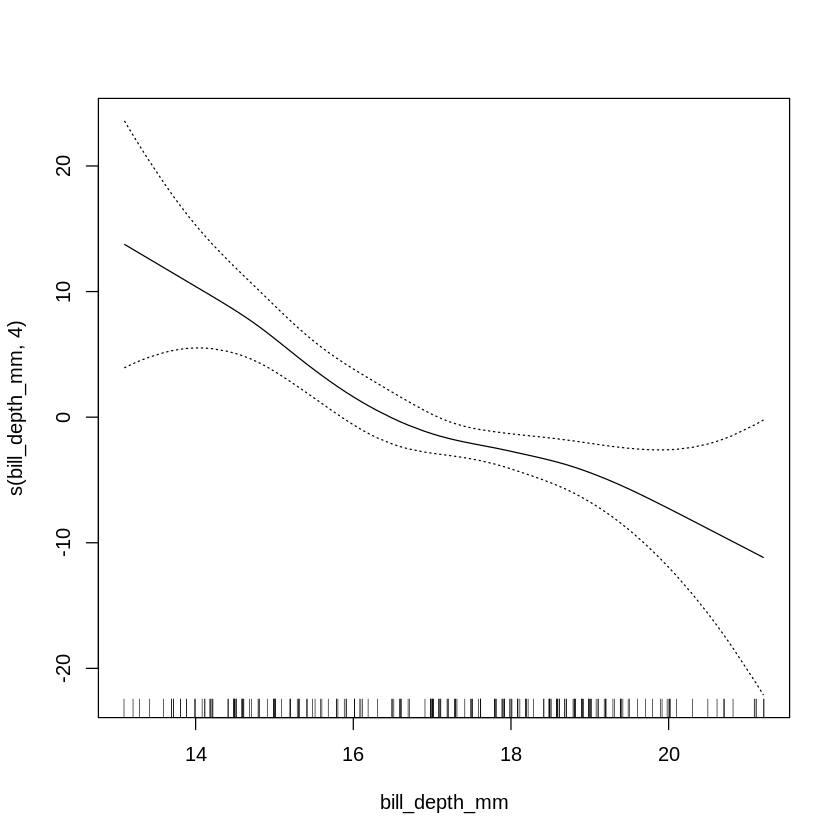

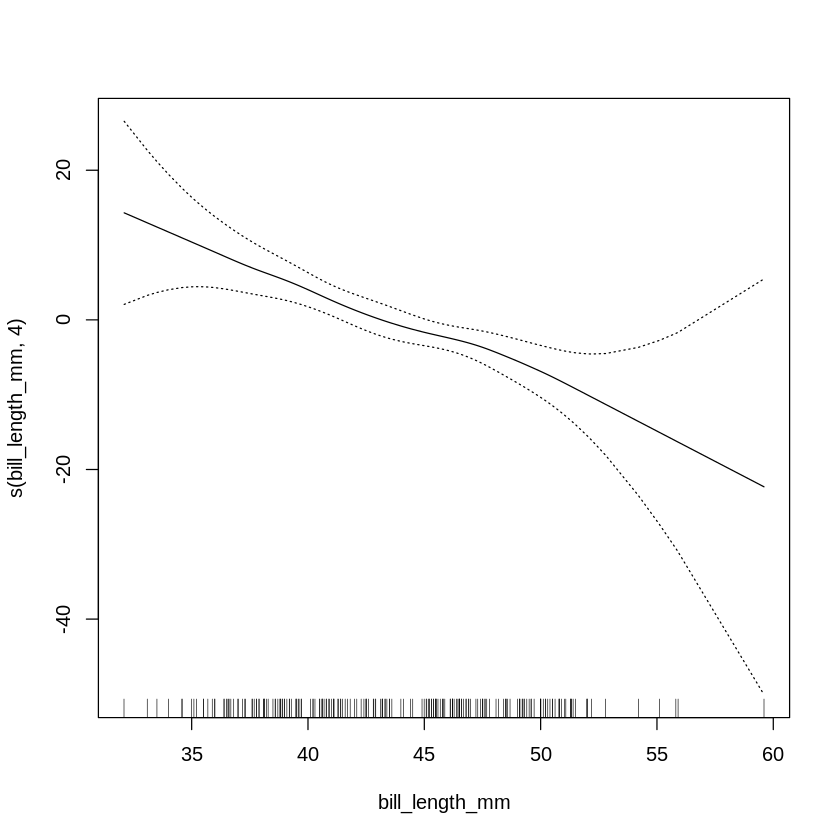

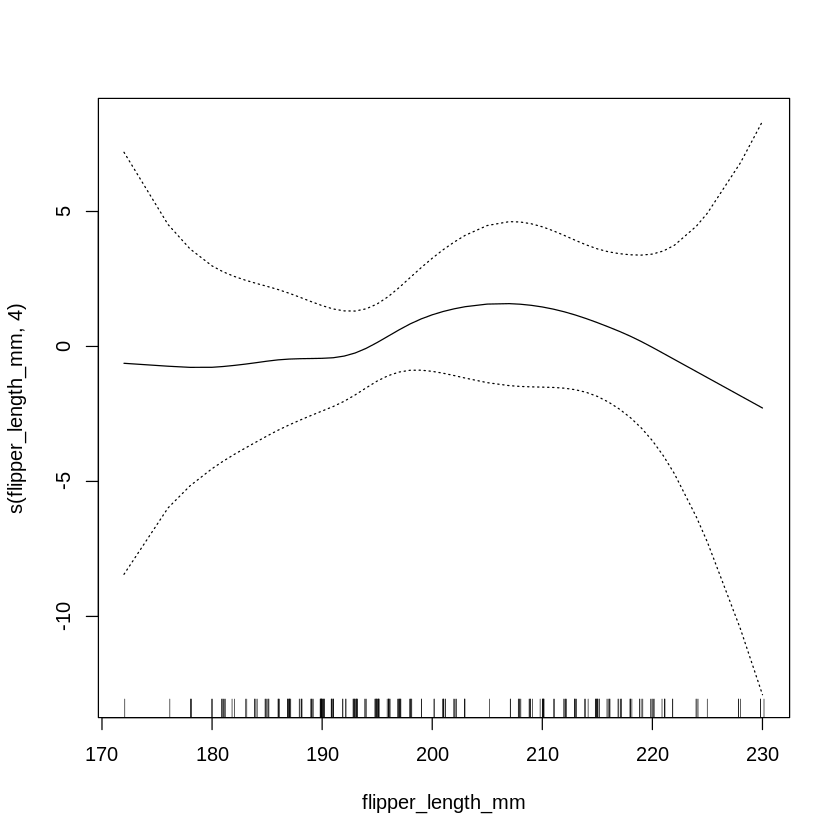

Warning message in gplot.default(x = c("Gentoo", "Chinstrap", "Adelie", "Gentoo", :
“The "x" component of "partial for species" has class "character"; no gplot() methods available”


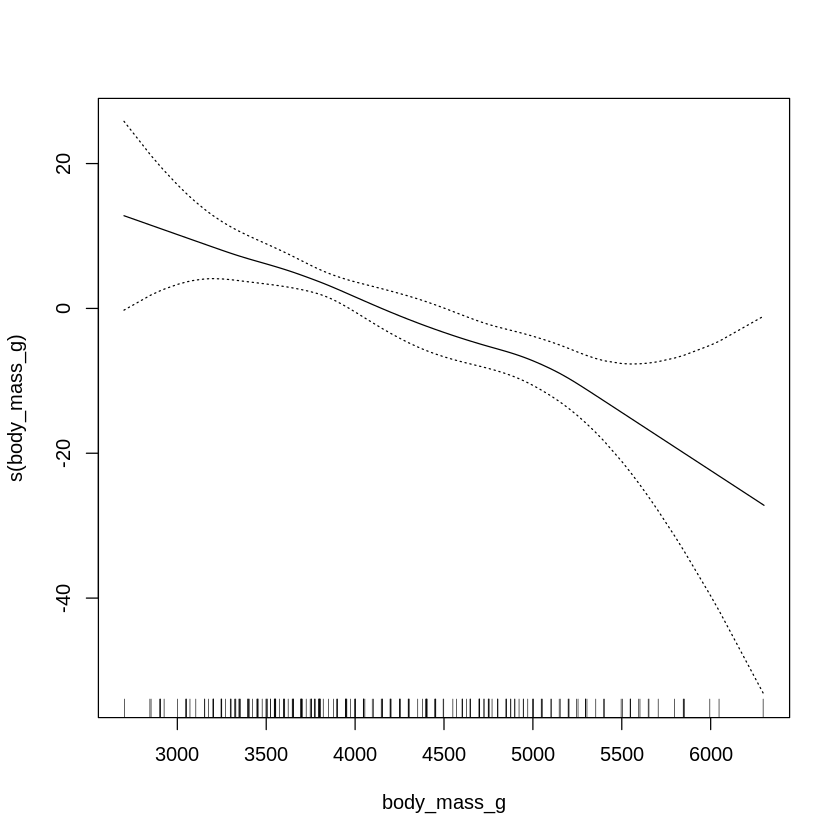

In [ ]:
penguins_gam <- gam(sex ~ s(bill_depth_mm, 4) + s(bill_length_mm, 4)
+ s(flipper_length_mm,4) + s(body_mass_g) + species ,
                             family = binomial,
                             data = penguins_train)

summary(penguins_gam)
plot.Gam(penguins_gam, se=TRUE)

Call:
rpart(formula = cnt ~ ., data = bike_train)
  n= 485 

           CP nsplit rel error    xerror       xstd
1  0.46496065      0 1.0000000 1.0045912 0.05021089
2  0.09072888      1 0.5350394 0.5461978 0.03424902
3  0.06295497      2 0.4443105 0.4678745 0.03396088
4  0.03262347      3 0.3813555 0.4061467 0.03652247
5  0.03005617      4 0.3487320 0.4211574 0.03805408
6  0.01392305      5 0.3186759 0.3922058 0.03346074
7  0.01278227      6 0.3047528 0.3823726 0.03330384
8  0.01233965      7 0.2919706 0.3782734 0.03330219
9  0.01085807      8 0.2796309 0.3776342 0.03333407
10 0.01058229      9 0.2687728 0.3725894 0.03277200
11 0.01000000     10 0.2581905 0.3733113 0.03283603

Variable importance
cnt_2d_bfr       temp     season  windspeed        hum    weekday    weather 
        40         25         18          7          7          3          1 

Node number 1: 485 observations,    complexity param=0.4649606
  mean=4495.703, MSE=3634106 
  left son=2 (243 obs) right son=3 (242 obs)

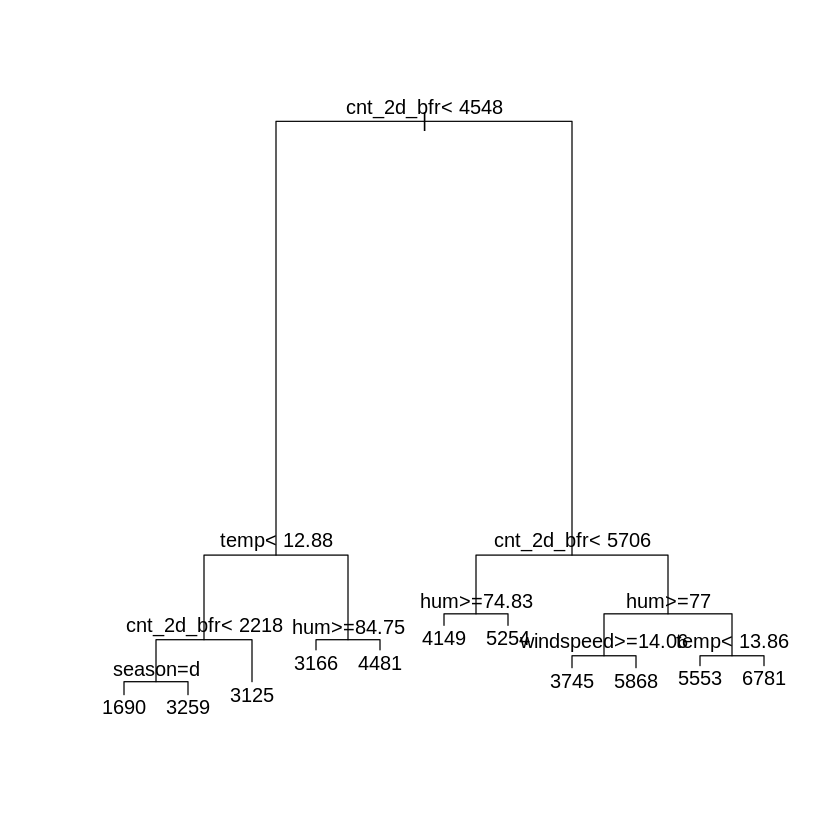

In [ ]:
## Decision Tree

## Bike

bike_tree <- rpart(cnt ~. , data = bike_train)

summary(bike_tree)

plot(bike_tree)
text(bike_tree)

In [ ]:
unique(bike_train$season)

[1] "SPRING" "FALL"   "WINTER" "SUMMER"

Call:
rpart(formula = sex ~ ., data = penguins_train)
  n= 222 

          CP nsplit rel error    xerror       xstd
1 0.46296296      0 1.0000000 1.1388889 0.06857565
2 0.24074074      1 0.5370370 0.6574074 0.06434539
3 0.06481481      2 0.2962963 0.3703704 0.05302314
4 0.01000000      3 0.2314815 0.3240741 0.05027529

Variable importance
      body_mass_g     bill_depth_mm flipper_length_mm    bill_length_mm 
               38                21                18                15 
          species 
                7 

Node number 1: 222 observations,    complexity param=0.462963
  predicted class=female  expected loss=0.4864865  P(node) =1
    class counts:   114   108
   probabilities: 0.514 0.486 
  left son=2 (136 obs) right son=3 (86 obs)
  Primary splits:
      bill_depth_mm     < 18.05  to the left,  improve=25.9832100, (0 missing)
      bill_length_mm    < 47.75  to the left,  improve=24.7347500, (0 missing)
      body_mass_g       < 3712.5 to the left,  improve=20.8131500, (0

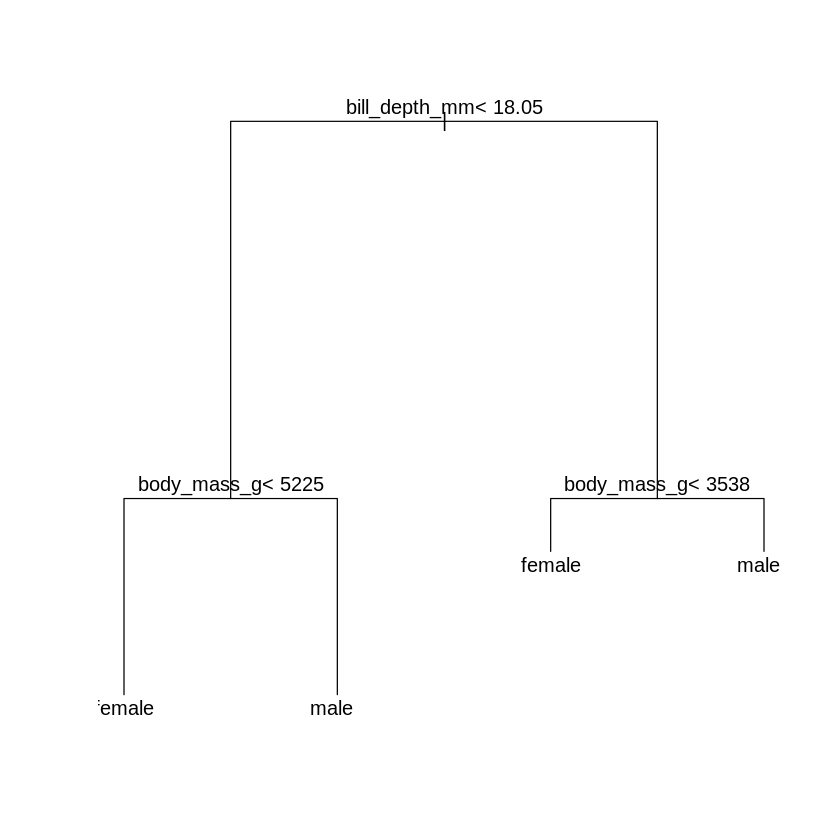

In [ ]:
penguins_train$sex <- factor(ifelse(penguins_train$sex == 1, "female", "male" ))
penguin_tree <- rpart(sex ~. , data = penguins_train)

summary(penguin_tree)

plot(penguin_tree)
text(penguin_tree)